In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


I0000 00:00:1735464719.037783   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464719.039219   74974 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464719.050748   74968 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


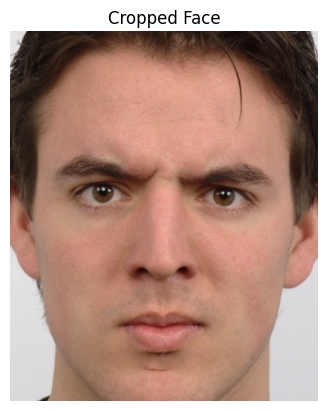

In [33]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt


def extract_face(image_path):
    # Load Mediapipe Face Detection
    mp_face_detection = mp.solutions.face_detection

    # Initialize the face detection model
    face_detection = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)

    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load image at {image_path}")
        return None

    height, width, _ = image.shape
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Detect faces
    results = face_detection.process(rgb_image)

    if results.detections:
        for detection in results.detections:
            bboxC = detection.location_data.relative_bounding_box
            x = int(bboxC.xmin * width)
            y = int(bboxC.ymin * height)
            w = int(bboxC.width * width)
            h = int(bboxC.height * height)

            # Adjust for forehead margin
            forehead_margin = int(0.2 * h)
            new_y = max(y - forehead_margin, 0)
            new_h = h + forehead_margin

            # Crop face
            return rgb_image[new_y:new_y + new_h, x:x + w]

    print(f"No face detected in {image_path}")
    return None



img_path = '../AULP/new_dataset/radboud/ANG/Rafd090_15_Caucasian_male_angry_frontal.jpg'
cropped_face = extract_face(img_path)

if cropped_face is not None:
    plt.imshow(cropped_face)
    plt.axis('off')  # Hide axes
    plt.title("Cropped Face")
    plt.show()


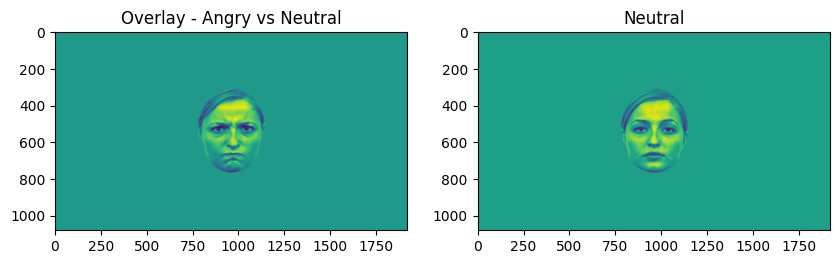

In [34]:
from helper import *
import os
import numpy as np
import pandas as pd
import argparse
from PIL import Image

from matplotlib import pyplot as plt

angry_path = '../AULP/new_dataset/Radboud_images/ANG/12_ANG.jpg'
neutral_path = '../AULP/new_dataset/Radboud_images/NUT/10_NUT.jpg'

# Load images
angry_img = Image.open(angry_path)
neutral_img = Image.open(neutral_path)

# Plot side by side and overlay
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(angry_img)
plt.title('Overlay - Angry vs Neutral')

plt.subplot(1, 2, 2)
plt.imshow(neutral_img)
plt.title('Neutral')

plt.show()

In [35]:
import os
import numpy as np
import pandas as pd
import argparse

from matplotlib import pyplot as plt

angry_path = '../AULP/new_dataset/radboud/ANG/Rafd090_15_Caucasian_male_angry_frontal.jpg'
neutral_path = '../AULP/new_dataset/radboud/NUT/Rafd090_09_Caucasian_male_neutral_frontal.jpg'

# Get landmark points for both images
b1_angry = np.array(getLandmarkPoints(angry_path))
b1_neutral = np.array(getLandmarkPoints(neutral_path))

# Apply affine and similarity transformations
_, b1_angry = affine_trans(b1_angry)
_, b1_angry = similarity_trans(b1_angry)

_, b1_neutral = affine_trans(b1_neutral)
_, b1_neutral = similarity_trans(b1_neutral)

# Plot side by side and overlay
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(b1_angry[:, 0], b1_angry[:, 1], color='red', label='Angry')
plt.scatter(b1_neutral[:, 0], b1_neutral[:, 1], color='blue', alpha=0.5, label='Neutral')
plt.title('Overlay - Angry vs Neutral')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(b1_neutral[:, 0], b1_neutral[:, 1])
plt.title('Neutral')

plt.show()


Processing ../AULP/new_dataset/radboud/ANG/Rafd090_15_Caucasian_male_angry_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_09_Caucasian_male_neutral_frontal.jpg


I0000 00:00:1735464719.973316   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464719.976000   74989 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464719.978416   74986 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464719.986974   74981 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464720.008407   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464720.009491   75004 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464720.013081   74990 inference_feedback_manager.cc:114] Feedback 

TypeError: affine_trans() missing 1 required positional argument: 'dst_matrix'

In [36]:
from helper import *
import os
import numpy as np
import pandas as pd
import argparse

from matplotlib import pyplot as plt

angry_path = '../AULP/new_dataset/radboud/ANG/Rafd090_01_Caucasian_female_angry_frontal.jpg'
neutral_path = '../AULP/new_dataset/radboud/NUT/Rafd090_01_Caucasian_female_neutral_frontal.jpg'

# Get landmark points for both images
pointsA_angry = np.array(getLandmarkPoints(angry_path))
pointsA_neutral = np.array(getLandmarkPoints(neutral_path))

# Apply affine and similarity transformations
_, points_angry = affine_trans(pointsA_angry)
_, b1_angry = similarity_trans(points_angry)

_, points_neutral = affine_trans(pointsA_neutral)
_, b1_neutral = similarity_trans(points_neutral)

# Plot side by side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(b1_angry[:, 0], b1_angry[:, 1])
plt.title('Angry')

plt.subplot(1, 2, 2)
plt.scatter(b1_neutral[:, 0], b1_neutral[:, 1])
plt.title('Neutral')

plt.show()


Processing ../AULP/new_dataset/radboud/ANG/Rafd090_01_Caucasian_female_angry_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_01_Caucasian_female_neutral_frontal.jpg


I0000 00:00:1735464720.711132   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464720.711910   75019 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464720.714238   75006 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464720.718718   75010 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464720.732136   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464720.732765   75034 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464720.734251   75026 inference_feedback_manager.cc:114] Feedback 

TypeError: affine_trans() missing 1 required positional argument: 'dst_matrix'

In [37]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd


def get_landmark_to_coordinates(image_path):
    # Initialize mediapipe Face Mesh
    mp_face_mesh = mp.solutions.face_mesh
    face_mesh = mp_face_mesh.FaceMesh()
    
    # image_path = './data/radboud/NUT/Rafd090_01_Caucasian_female_neutral_frontal.jpg'
    image = cv2.imread(image_path)
    
    h,w,_ = image.shape
    
    # Convert BGR image to RGB for processing
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result = face_mesh.process(image_rgb)
    
    landmark_to_coordinates = {}
    
    landmark_indices = [i for i in range(0,468)]
    
    if result.multi_face_landmarks:
        for face_landmarks in result.multi_face_landmarks:
            h, w, _ = image.shape
            
            for idx in landmark_indices:
                # Get the position of the landmark
                lm = face_landmarks.landmark[idx]
                x, y = int(lm.x * w), int(lm.y * h)
    
                landmark_to_coordinates[idx] = [x,y]
    return landmark_to_coordinates

In [38]:
landmark_to_coordinates

dst_matrix = [landmark_to_coordinates[x] for x in landmark_to_coordinates]


In [39]:
angry_path = '../AULP/new_dataset/iim/ANG/DST_002_F_ANG.jpg'
points = np.array(getLandmarkPoints(angry_path))

Processing ../AULP/new_dataset/iim/ANG/DST_002_F_ANG.jpg


I0000 00:00:1735464723.166848   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464723.167803   75050 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464723.169787   75038 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464723.174159   75047 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [48]:
pip install face-alignment



SyntaxError: invalid syntax (3595467345.py, line 1)

In [47]:
import cv2
import numpy as np
import dlib
import matplotlib.pyplot as plt

# Load image and detector
image = cv2.imread("../AULP/new_dataset/radboud/SAD/Rafd090_01_Caucasian_female_sad_frontal.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB for Matplotlib
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# Detect face and landmarks
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
faces = detector(gray)

for face in faces:
    landmarks = predictor(gray, face)
    
    # Get key points: left eye (36), right eye (45), and nose tip (30)
    left_eye = (landmarks.part(36).x, landmarks.part(36).y)
    right_eye = (landmarks.part(45).x, landmarks.part(45).y)
    nose_tip = (landmarks.part(30).x, landmarks.part(30).y)
    
    # Define reference points in the canonical view
    ref_points = np.array([
        [0.3 * image.shape[1], 0.4 * image.shape[0]],  # Left eye
        [0.7 * image.shape[1], 0.4 * image.shape[0]],  # Right eye
        [0.5 * image.shape[1], 0.6 * image.shape[0]]   # Nose tip
    ], dtype="float32")
    
    # Current points
    src_points = np.array([left_eye, right_eye, nose_tip], dtype="float32")
    
    # Compute affine transform
    matrix = cv2.getAffineTransform(src_points, ref_points)
    
    # Apply transformation
    warped = cv2.warpAffine(image, matrix, (image.shape[1], image.shape[0]))
    warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)  # Convert to RGB for Matplotlib
    
    # Plot original and frontalized faces
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Original face
    axes[0].imshow(image_rgb)
    axes[0].set_title("Original Face")
    axes[0].axis("off")
    
    # Frontalized face
    axes[1].imshow(warped_rgb)
    axes[1].set_title("Frontalized Face")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    break  # Process the first face only


RuntimeError: Unable to open shape_predictor_68_face_landmarks.dat

In [40]:

def similarity_trans(kp,matrix=None):

    # Registering right eyebrows and eyes
    src = kp[[130,133]]
    dst = np.array([landmark_to_coordinates[130],landmark_to_coordinates[133]])
    tform = SimilarityTransform()
    tform.estimate(src, dst)

    # Keypoints related to right eyebrow and eyes -> https://github.com/tensorflow/tfjs-models/blob/838611c02f51159afdd77469ce67f0e26b7bbb23/face-landmarks-detection/src/mediapipe-facemesh/keypoints.ts
    right_eye_kps = [246, 161, 160, 159, 158, 157, 173,33, 7, 163, 144, 145, 153, 154, 155, 133,247, 30, 29, 27, 28, 56, 190,130, 25, 110, 24, 23, 22, 26, 112, 243,113, 225, 224, 223, 222, 221, 189,226, 31, 228, 229, 230, 231, 232, 233, 244]
    kp[right_eye_kps] = tform(kp[right_eye_kps])


    # Registering left eyebrows and eyes
    src = kp[[463, 359]]
    dst = np.array([landmark_to_coordinates[463],landmark_to_coordinates[359]])
    tform = SimilarityTransform()
    tform.estimate(src, dst)
    left_eye_kps = [466, 388, 387, 386, 385, 384, 398,263, 249, 390, 373, 374, 380, 381, 382, 362,467, 260, 259, 257, 258, 286, 414,359, 255, 339, 254, 253, 252, 256, 341, 463,342, 445, 444, 443, 442, 441, 413,446, 261, 448, 449, 450, 451, 452, 453, 464]
    kp[left_eye_kps] = tform(kp[left_eye_kps])

    # Registering jawline
    src = kp[[162, 389]]
    dst = np.array([landmark_to_coordinates[162],landmark_to_coordinates[389]])
    tform = SimilarityTransform()
    tform.estimate(src, dst)
    jawline_kps = [
    10,  338, 297, 332, 284, 251, 389, 356, 454, 323, 361, 288,
    397, 365, 379, 378, 400, 377, 152, 148, 176, 149, 150, 136,
    172, 58,  132, 93,  234, 127, 162, 21,  54,  103, 67,  109
    ]
    kp[jawline_kps] = tform(kp[jawline_kps])

    return np.array(matrix), kp



def affine_trans(kp,data_name=None, matrix=None):

    '''
    # 162 -> 300,1000
    # 190 -> 600,900
    414 -> 800,1000
    # 168 -> 700,900
    # 10 -> 700, 1300
    # 1 -> 700, 600
    205 -> 500, 600
    425 -> 900, 600
    # 152 -> 500. 100
    # 389 -> 1000,1000
'''
    src = np.float32([kp[i] for i in range(0,468)])

    # src = np.float32[src]

    # src = np.float32([kp[162], kp[368], kp[6], kp[1], kp[133], kp[463]])
    dst = np.float32(dst_matrix)
    src_h = np.concatenate((src.T, np.ones(src.shape[0]).reshape(1,src.shape[0])), axis=0)
    dst_h = np.concatenate((dst.T, np.ones(dst.shape[0]).reshape(1,dst.shape[0])), axis=0)
    
    kp_h = np.concatenate((kp.T, np.ones(kp.shape[0]).reshape(1,kp.shape[0])), axis=0)
    
    if matrix is None: matrix = dst_h@np.linalg.pinv(src_h)
    kp_h = matrix@kp_h
    
    return matrix, kp_h[:2, :].T

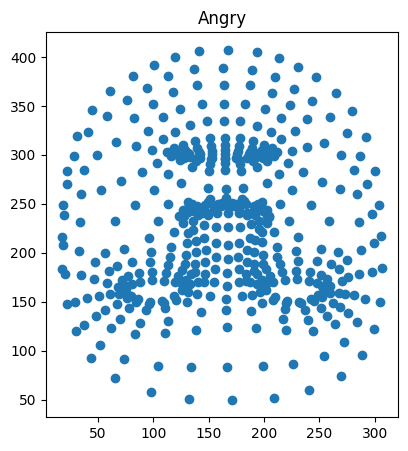

In [41]:
# Apply affine and similarity transformations
_, b1_angry = affine_trans(points)
_,b1_angry = similarity_trans(b1_angry)

# Plot side by side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(b1_angry[:, 0], b1_angry[:, 1])
plt.title('Angry')

# plt.subplot(1, 2, 2)
# plt.scatter(b1_neutral[:, 0], b1_neutral[:, 1])
# plt.title('Neutral')

plt.show()

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_01_Caucasian_female_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_01_Caucasian_female_neutral_frontal.jpg


I0000 00:00:1735464726.818128   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464726.818880   75065 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464726.820526   75058 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464726.825693   75052 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464726.836793   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464726.837594   75080 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464726.839449   75070 inference_feedback_manager.cc:114] Feedback 

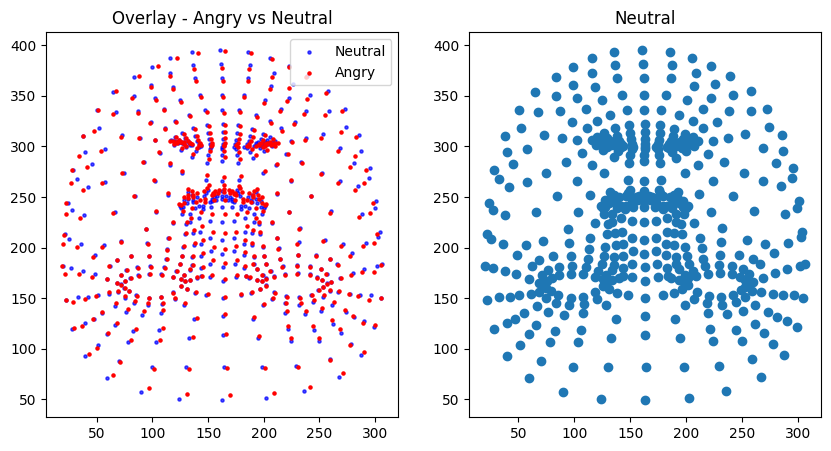

240.9920516374963 353.66662128677126


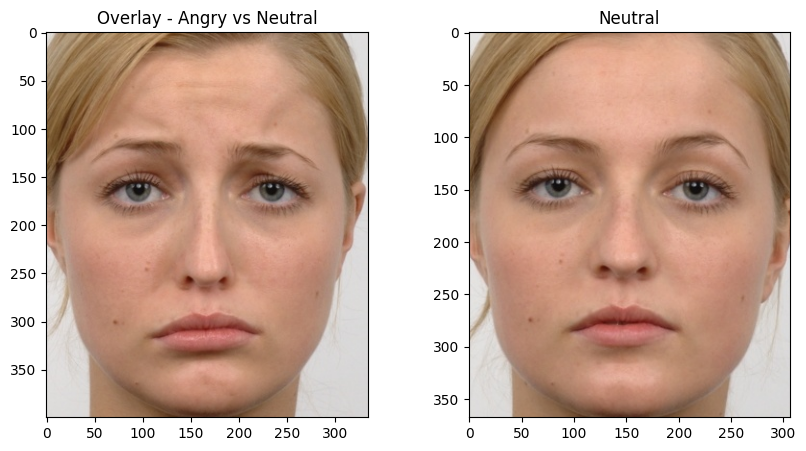

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_02_Caucasian_female_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_02_Caucasian_female_neutral_frontal.jpg


I0000 00:00:1735464727.255007   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464727.255973   75096 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464727.257634   75084 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464727.264329   75086 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464727.274070   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464727.274767   75111 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464727.276395   75097 inference_feedback_manager.cc:114] Feedback 

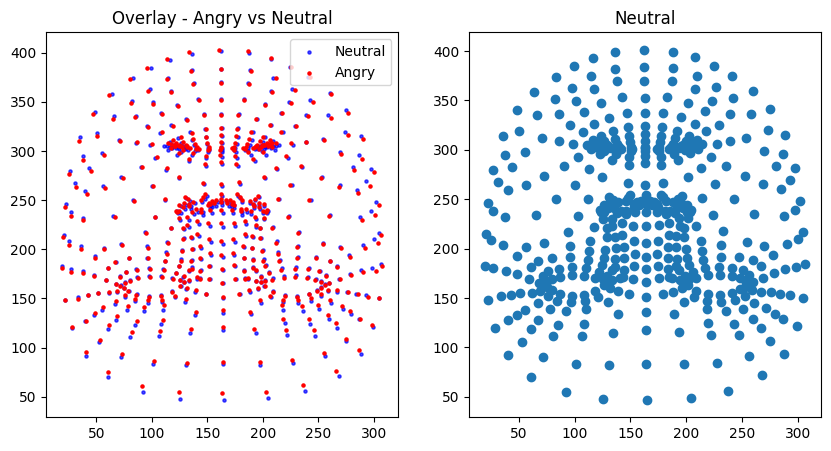

-85.31058606885303 326.3194696124393


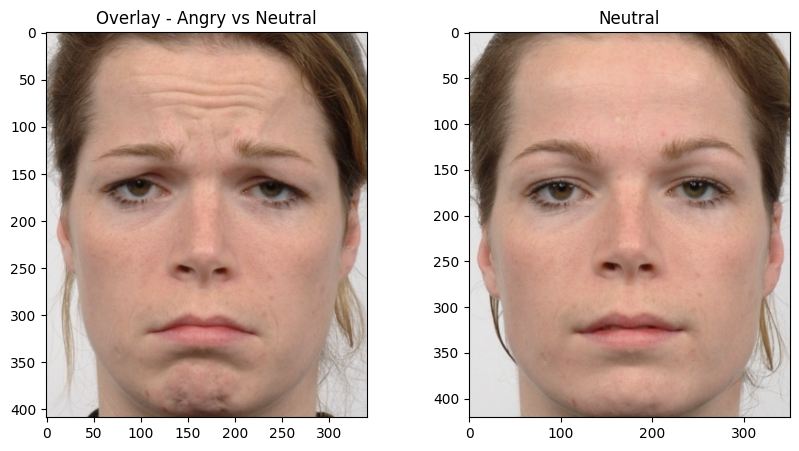

I0000 00:00:1735464727.824110   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464727.825081   75126 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464727.826788   75117 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464727.830261   75120 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464727.844713   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464727.846463   75141 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464727.849450   75130 inference_feedback_manager.cc:114] Feedback 

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_03_Caucasian_male_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_03_Caucasian_male_neutral_frontal.jpg


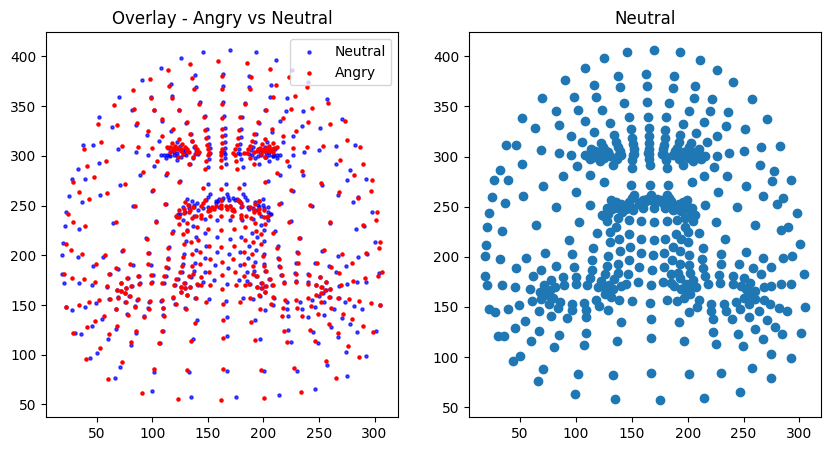

-510.9868564959026 -281.1253252012153


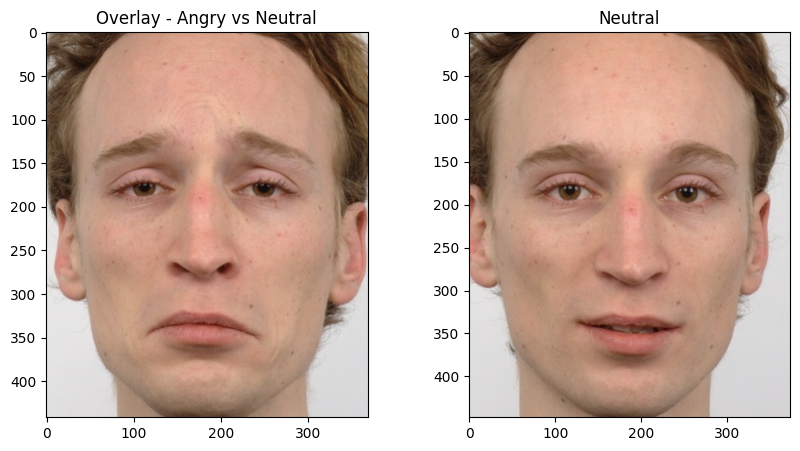

I0000 00:00:1735464728.279615   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464728.280350   75156 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464728.281989   75147 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464728.285704   75149 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464728.296310   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464728.296966   75171 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464728.298993   75161 inference_feedback_manager.cc:114] Feedback 

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_04_Caucasian_female_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_04_Caucasian_female_neutral_frontal.jpg


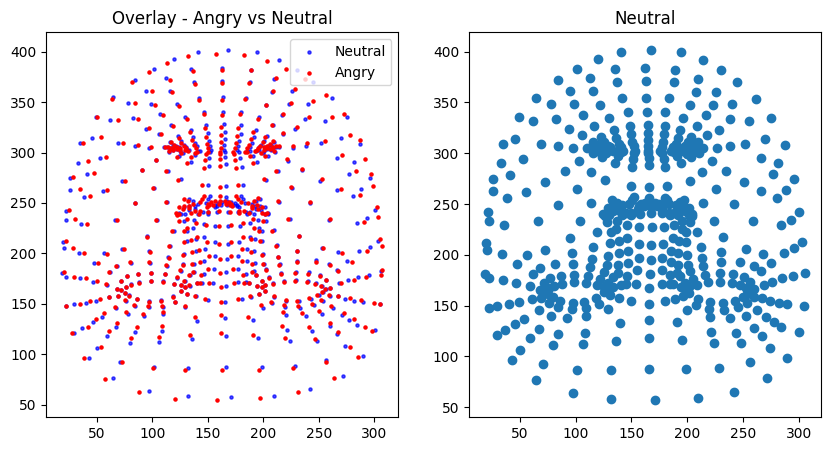

-531.2384596166145 37.406704012724035


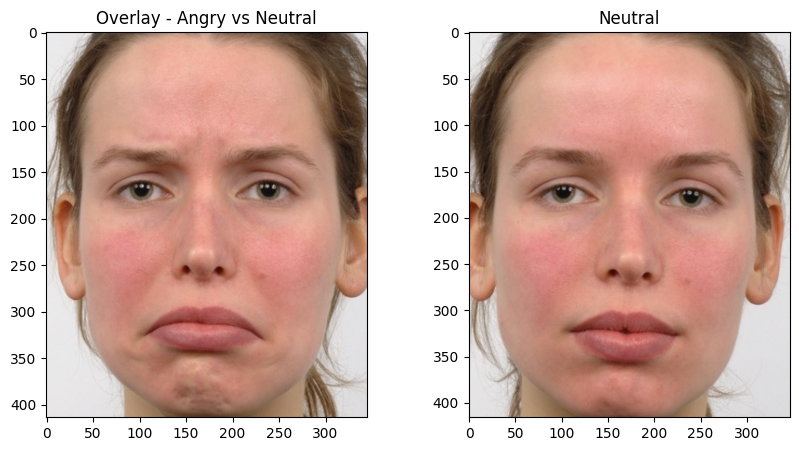

I0000 00:00:1735464728.725014   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464728.725687   75186 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464728.727889   75177 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464728.733188   75179 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464728.742808   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464728.743397   75201 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464728.745240   75197 inference_feedback_manager.cc:114] Feedback 

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_05_Caucasian_male_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_05_Caucasian_male_neutral_frontal.jpg


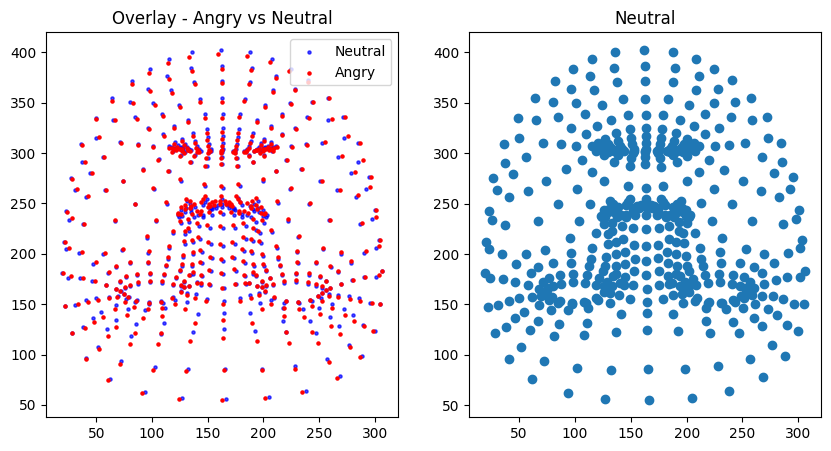

-148.6153159484554 -197.06601754927823


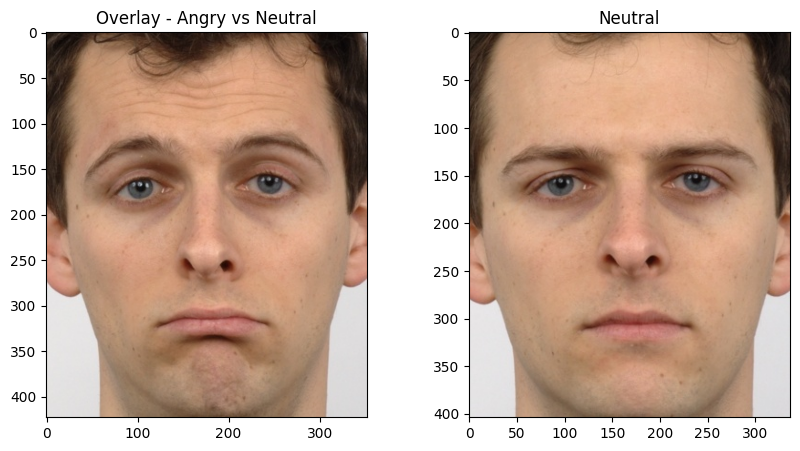

I0000 00:00:1735464729.171529   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464729.172196   75216 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464729.174202   75210 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464729.177721   75205 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464729.188466   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464729.190128   75231 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464729.191766   75222 inference_feedback_manager.cc:114] Feedback 

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_07_Caucasian_male_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_07_Caucasian_male_neutral_frontal.jpg


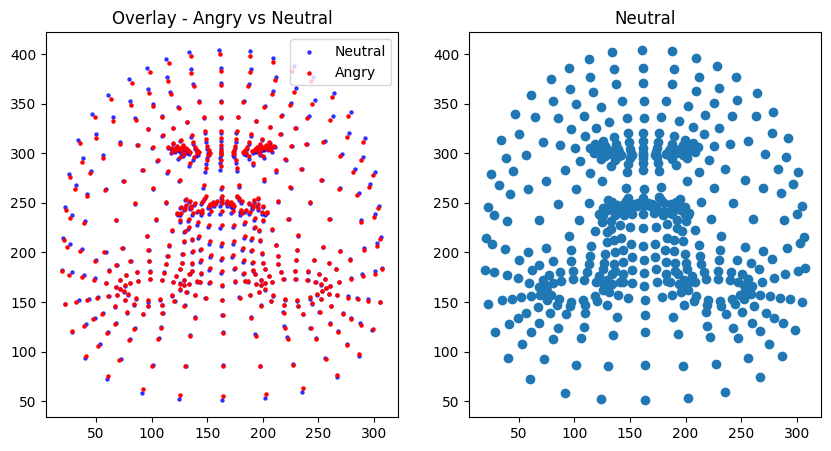

51.47651533149141 147.28064621114592


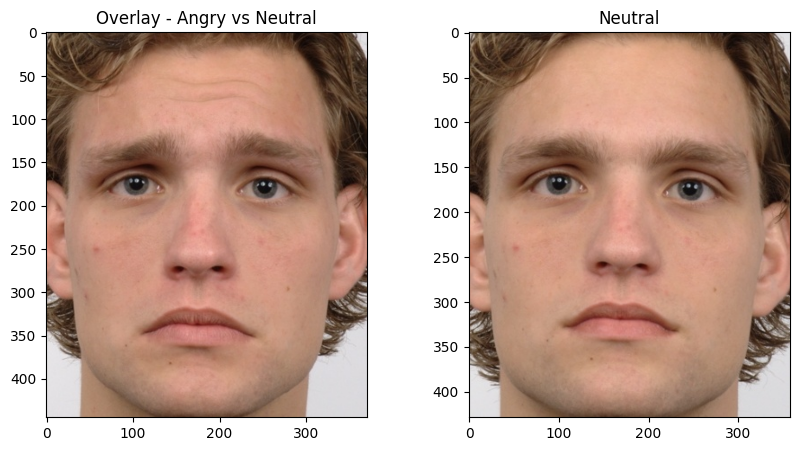

I0000 00:00:1735464729.606113   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464729.606901   75246 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464729.610071   75239 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464729.616062   75243 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464729.625481   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464729.626946   75261 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464729.632756   75247 inference_feedback_manager.cc:114] Feedback 

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_08_Caucasian_female_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_08_Caucasian_female_neutral_frontal.jpg


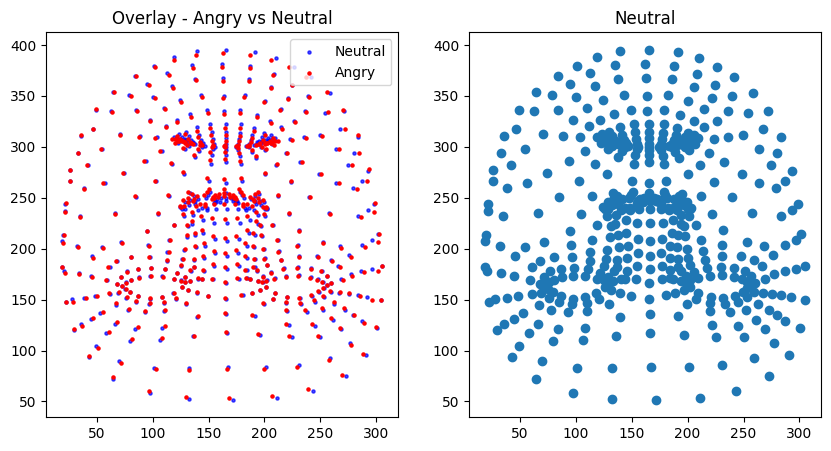

-145.26596830940872 163.87419702008071


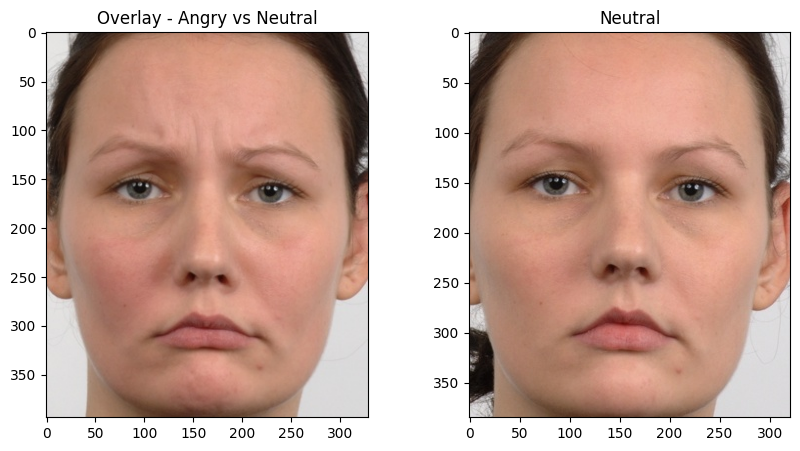

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_09_Caucasian_male_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_09_Caucasian_male_neutral_frontal.jpg


I0000 00:00:1735464730.228495   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464730.229243   75276 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464730.230988   75264 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464730.237309   75271 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464730.247868   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464730.248590   75291 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464730.250076   75280 inference_feedback_manager.cc:114] Feedback 

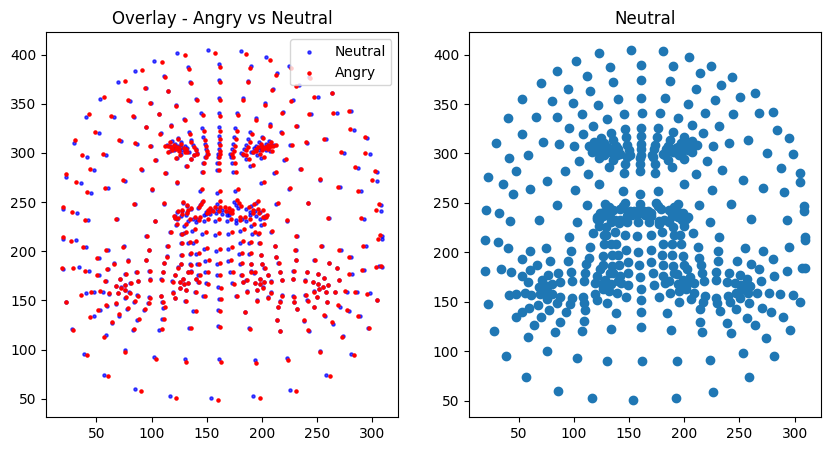

275.2706039245808 44.981335208011785


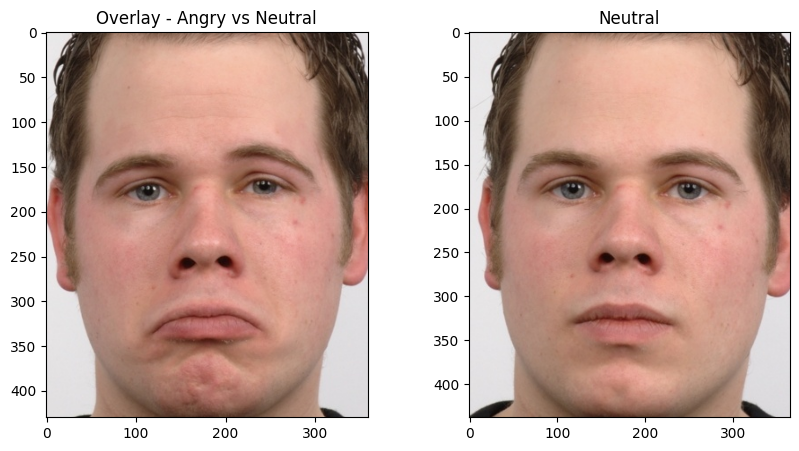

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_10_Caucasian_male_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_10_Caucasian_male_neutral_frontal.jpg


I0000 00:00:1735464730.656309   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464730.657383   75306 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464730.659171   75293 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464730.662815   75302 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464730.672482   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464730.673171   75321 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464730.675090   75313 inference_feedback_manager.cc:114] Feedback 

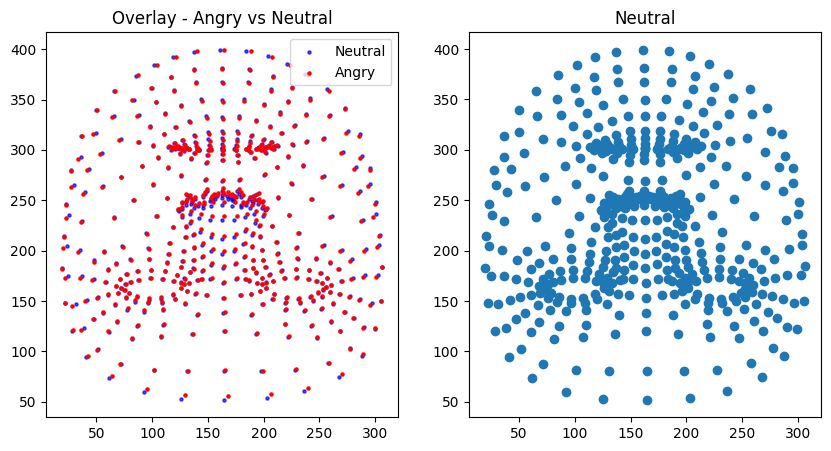

133.27969862494072 155.32276405789568


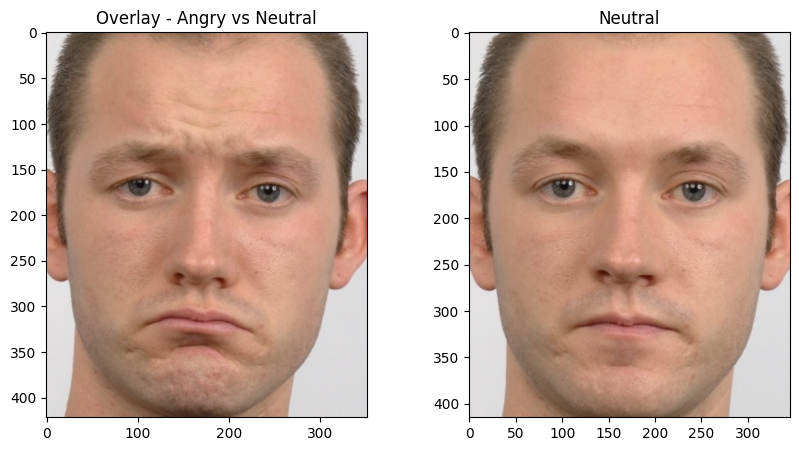

I0000 00:00:1735464731.111659   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464731.112393   75336 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464731.114255   75331 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1735464731.119409   75323 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1735464731.130247   55643 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1735464731.130927   75351 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.2), renderer: Mesa Intel(R) UHD Graphics (TGL GT1)
W0000 00:00:1735464731.132362   75337 inference_feedback_manager.cc:114] Feedback 

Processing ../AULP/new_dataset/radboud/SAD/Rafd090_12_Caucasian_female_sad_frontal.jpg
Processing ../AULP/new_dataset/radboud/NUT/Rafd090_12_Caucasian_female_neutral_frontal.jpg


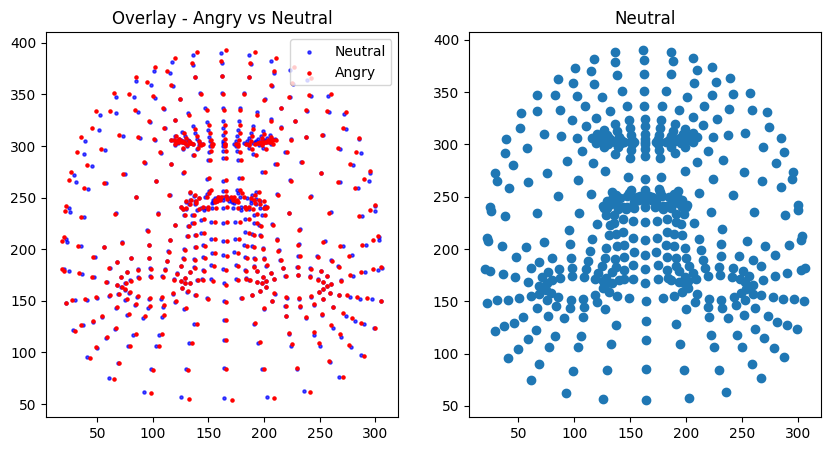

286.6034474216342 15.803003009127835


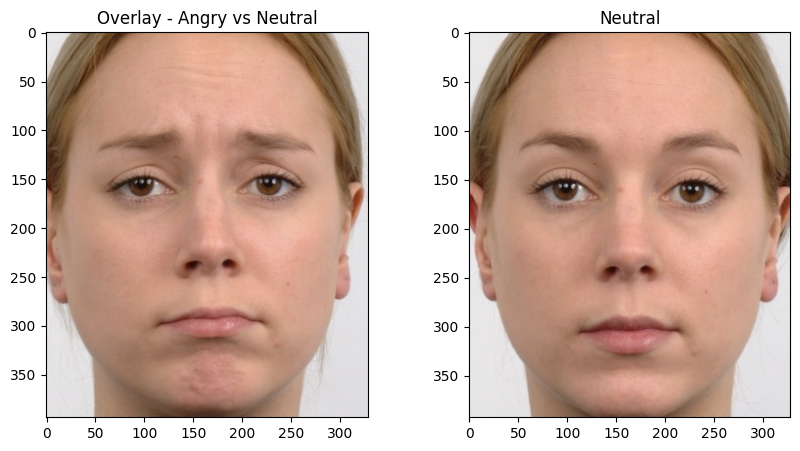

In [42]:
import os
import numpy as np
import pandas as pd
import argparse
import warnings
warnings.filterwarnings("ignore")

from matplotlib import pyplot as plt

# angry_path = '../AULP/new_dataset/Radboud_images/ANG/12_ANG.jpg'
# neutral_path = '../AULP/new_dataset/Radboud_images/NUT/10_NUT.jpg'
# angry_path = './data/radboud/ANG/Rafd090_10_Caucasian_male_angry_frontal.jpg'
# neutral_path = './data/radboud/NUT/Rafd090_10_Caucasian_male_neutral_frontal.jpg'
# angry_path = '../AULP/new_dataset/Radboud_images/ANG/12_ANG.jpg'
# neutral_path = '../AULP/new_dataset/Radboud_images/NUT/10_NUT.jpg'

angry_paths = os.listdir('../AULP/new_dataset/radboud/SAD/')
neutral_paths  = os.listdir('../AULP/new_dataset/radboud/NUT')

angry_paths.sort()
neutral_paths.sort()

# angry_paths = ['../AULP/cropped_face.png']
# neutral_paths = ['../AULP/cropped_face1.png']

i = 0
for angry_path,neutral_path in zip(angry_paths,neutral_paths):
    angry_path = '../AULP/new_dataset/radboud/SAD/' + angry_path
    neutral_path = '../AULP/new_dataset/radboud/NUT/' +neutral_path


    # Get landmark points for both images
    b1_angry = np.array(getLandmarkPoints(angry_path))
    b1_neutral = np.array(getLandmarkPoints(neutral_path))
    
    # Apply affine and similarity transformations
    _, b1_angry = affine_trans(b1_angry)
    _, b1_angry = similarity_trans(b1_angry)
    
    _, b1_neutral = affine_trans(b1_neutral)
    _, b1_neutral = similarity_trans(b1_neutral)
    
    # Plot side by side and overlay
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(b1_neutral[:, 0], b1_neutral[:, 1], color='blue', alpha=0.7,s=5, label='Neutral')
    plt.scatter(b1_angry[:, 0], b1_angry[:, 1], color='red',s=5, label='Angry')
    
    plt.title('Overlay - Angry vs Neutral')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.scatter(b1_neutral[:, 0], b1_neutral[:, 1])
    plt.title('Neutral')
    
    plt.show()
    
    print(sum(b1_angry[:, 0] -b1_neutral[:, 0]),sum(b1_angry[:, 1] -b1_neutral[:, 1]) )
    
    import os
    import numpy as np
    import pandas as pd
    import argparse
    from PIL import Image
    
    from matplotlib import pyplot as plt
    
    # Load images
    angry_img = Image.open(angry_path)
    neutral_img = Image.open(neutral_path)
    
    # Plot side by side and overlay
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(angry_img)
    plt.title('Overlay - Angry vs Neutral')
    
    plt.subplot(1, 2, 2)
    plt.imshow(neutral_img)
    plt.title('Neutral')
    
    plt.show()
    i+=1
    if i == 10:
        break

In [ ]:
src =
dst = np.float32(dst_matrix)

In [42]:
# Cell for configs

RANDOM_SEED = 99

In [43]:

def get_both_components(intersection):
    '''
        Get both x and y components/coordinates for intersecting landmark points
    '''
    new_array = []
    for element in intersection:
        new_array.append(element)  # Add the element itself
        if element % 2 == 0:  # Check if even
            new_array.append(element +1)
        else:  # If odd
            new_array.append(element -1)
    
    final_array = np.array(sorted(list(set(new_array))))
    return final_array

def plot_vectors(vectors,dataset_name):
    # Prepare the origin points (set to (0, 0) for all vectors)
    origin_x = np.zeros(vectors.shape[0])
    origin_y = np.zeros(vectors.shape[0])
    
    # Separate the x and y components of the vectors
    vector_x = vectors[:, 0]
    vector_y = vectors[:, 1]
    
    # Plot the vectors
    plt.figure(figsize=(8, 8))
    plt.quiver(origin_x, origin_y, vector_x, vector_y, angles='xy', scale_units='xy', scale=1, color='r')
    plt.xlim(-20000, 20000)
    plt.ylim(-20000, 20000)
    plt.grid()
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title(dataset_name)
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

def get_angles(vectors):
    '''
        Returns angles made by vectors in degrees
    '''
    angles_radians = np.arctan2(vectors[:, 1], vectors[:, 0])

    # Convert angles to degrees
    angles_degrees = np.degrees(angles_radians)
    
    # Normalize negative angles to be in the range [0, 360]
    angles_degrees = np.where(angles_degrees < 0, angles_degrees + 360, angles_degrees)

    return angles_degrees

def get_resultant_vector(df: pd.DataFrame):
    '''
        Returns resultant vector list (2d array) and magnitude list (magnitude of resultant vector)
    '''
    vectors = []
    list_magnitude = []
    # Compute resultant vectors
    for i in range(df.shape[0]):
        row = list(df.iloc[i])
        resultant_vector = np.array([sum(row[0::2]), sum(row[1::2])])
        list_magnitude.append(np.linalg.norm(resultant_vector))
        vectors.append(resultant_vector)

    return np.array(vectors),list_magnitude

# ANG

In [44]:
#ANG
iim_ang = np.array([21, 37, 65, 87, 117, 167, 213, 219, 265, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 365, 385, 389, 399, 401, 403, 405, 409, 417, 421, 423, 425, 429, 431, 525, 547, 577, 627, 671, 677, 723, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 813, 833, 837, 843, 845, 849, 857, 861, 863, 865, 869, 871])
jaffe_ang = np.array([33, 35, 37, 65, 87, 117, 167, 169, 171, 183, 213, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 363, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 429, 525, 547, 627, 629, 631, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 811, 813, 837, 843, 845, 849, 857, 861, 863])
radboud_ang = np.array([37, 65, 87, 117, 167, 213, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 365, 385, 389, 399, 401, 403, 405, 409, 417, 421, 423, 429, 431, 525, 577, 627, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 813, 837, 843, 845, 849, 857, 861, 863, 869, 871])

intersection = np.intersect1d(radboud_ang, jaffe_ang)

In [45]:
intersection = get_both_components(intersection)

(500, 108)


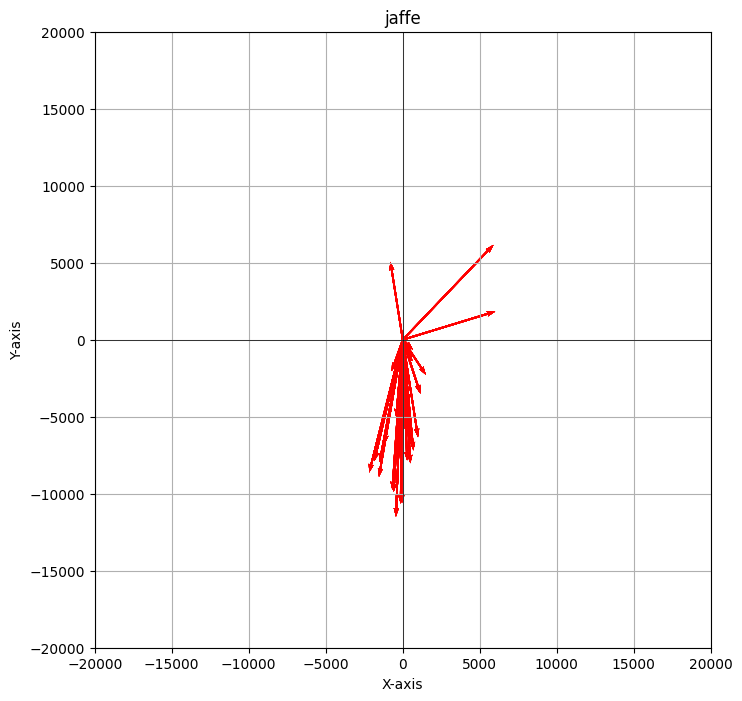

In [46]:
# Processing Jaffe

#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/jaffe/ANG.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

jaffe_vectors,jaffe_magnitude =get_resultant_vector(df)

jaffe_angles = get_angles(jaffe_vectors)

plot_vectors(jaffe_vectors,'jaffe')

(500, 108)


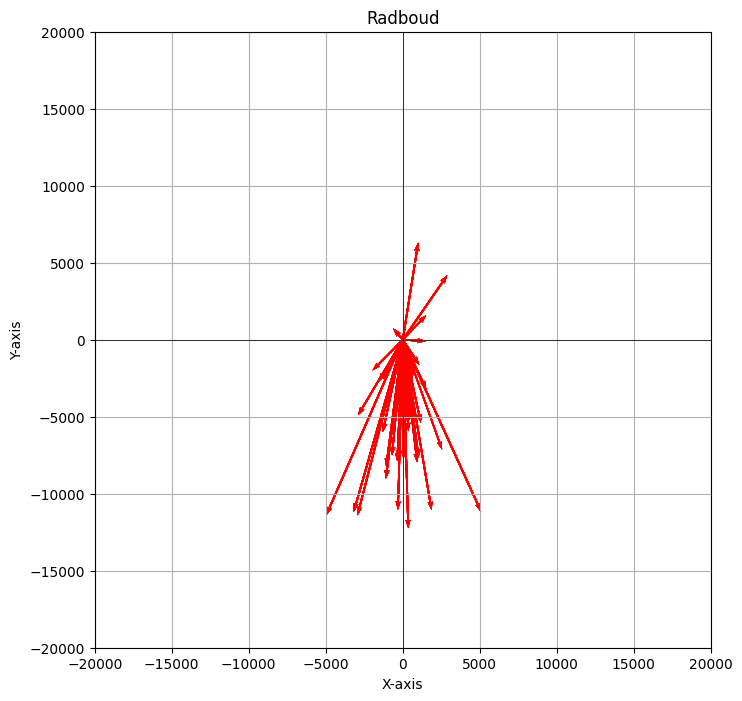

In [47]:
# Processing Radboud

#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/radboud/ANG.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

radboud_vectors,radboud_magnitude =get_resultant_vector(df)

radboud_angles = get_angles(radboud_vectors)

plot_vectors(radboud_vectors,'Radboud')

Skewness of JAFFE(ANG): -0.107
Skewness of RADBOUD(ANG): 0.358


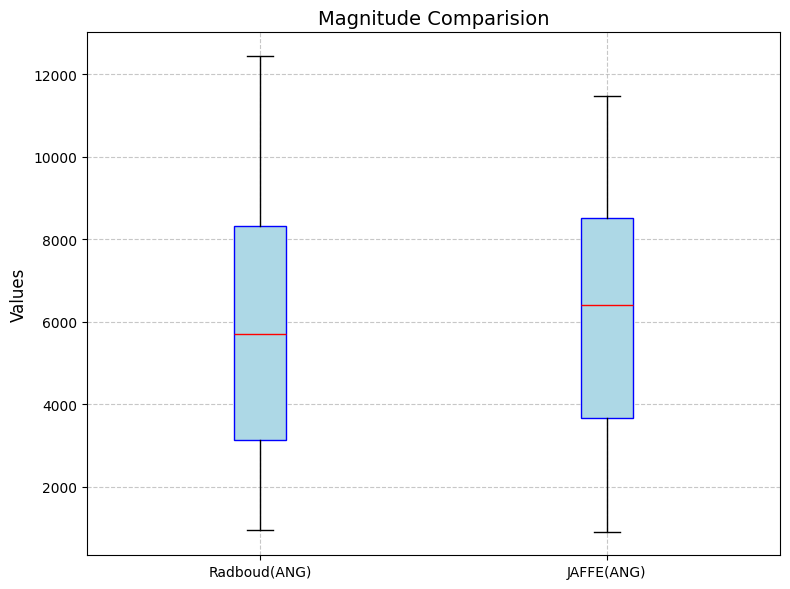

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew


# Calculate skewness
radboud_skewness = skew(radboud_magnitude)
jaffe_skewness = skew(jaffe_magnitude)

# Print skewness
print(f"Skewness of JAFFE(ANG): {jaffe_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {radboud_skewness:.3f}")


# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [np.array(radboud_magnitude), np.array(jaffe_magnitude)]
ax.boxplot(boxplot_data, labels=['Radboud(ANG)', 'JAFFE(ANG)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Magnitude Comparision', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


Skewness of IIM(ANG): -2.048
Skewness of RADBOUD(ANG): -2.478


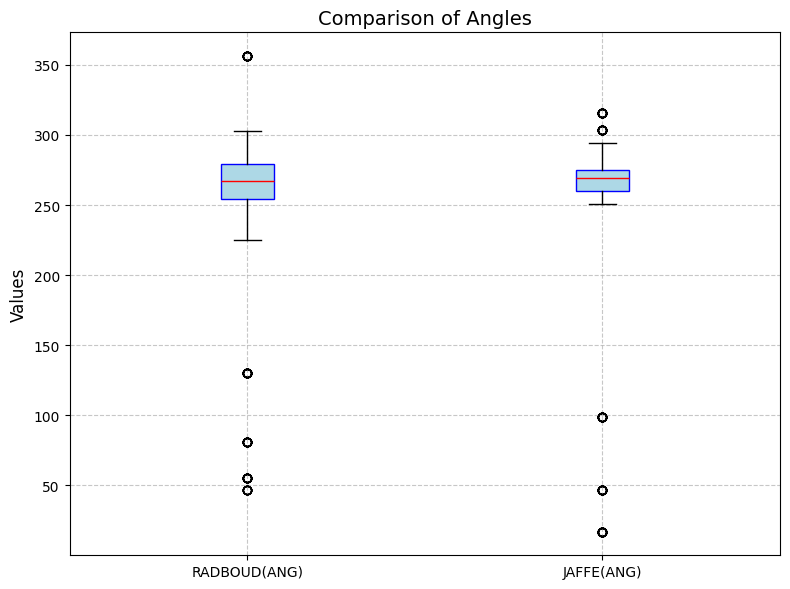

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")


# Calculate skewness
radboud_skewness = skew(radboud_angles)
jaffe_skewness = skew(jaffe_angles)

# Print skewness
print(f"Skewness of IIM(ANG): {radboud_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [radboud_angles, jaffe_angles]
ax.boxplot(boxplot_data, labels=['RADBOUD(ANG)', 'JAFFE(ANG)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Comparison of Angles', fontsize=14)
ax.set_ylabel('Values', fontsize=12)


# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [51]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(radboud_angles, jaffe_angles, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the angles.")
else:
    print("There is no significant difference between the angles.")


Mann-Whitney U Test Statistic: 119819.0, p-value: 0.25655469974680534
There is no significant difference between the angles.


In [52]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(radboud_magnitude, jaffe_magnitude, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 122950.0, p-value: 0.653534596996374
There is no significant difference between the magnitudes


In [53]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = radboud_vectors # 10 vectors in group 1
array2 = jaffe_vectors  # 10 vectors in group 2

# Combine arrays and create unique labels
data = np.vstack([array1, array2])
labels = [f'Group1_{i}' for i in range(len(array1))] + [f'Group2_{i}' for i in range(len(array2))]

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=['Group1'] * len(array1) + ['Group2'] * len(array2))
print(result)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1000
number of groups                  2
test statistic             2.210357
p-value                       0.127
number of permutations          999
Name: PERMANOVA results, dtype: object


# HPY

In [54]:
# #HPY
iim_hpy = np.array([21, 37, 65, 117, 167, 213, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 365, 385, 389, 399, 401, 403, 405, 409, 417, 421, 423, 429, 431, 525, 547, 577, 627, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 813, 833, 837, 843, 845, 849, 857, 861, 863, 869, 871])
jaffe_hpy = np.array([31, 33, 35, 37, 65, 87, 167, 169, 171, 183, 213, 271, 273, 281, 297, 299, 301, 305, 339, 341, 343, 351, 353, 361, 363, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 525, 627, 629, 631, 671, 729, 731, 739, 755, 757, 759, 789, 791, 793, 801, 811, 813, 837, 843, 849, 857, 861, 863])
radboud_hpy = np.array([31, 33, 35, 37, 65, 167, 169, 171, 173, 183, 213, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 361, 363, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 525, 627, 629, 631, 633, 643, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 809, 811, 813, 837, 843, 849, 857, 861, 863])

intersection = np.intersect1d(radboud_hpy, jaffe_hpy)

In [55]:
intersection = get_both_components(intersection)

(500, 114)


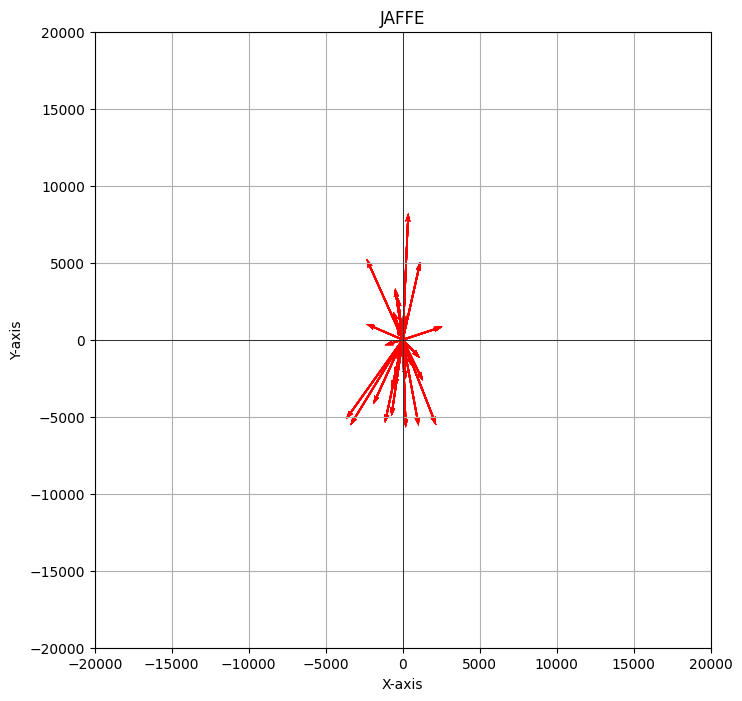

In [56]:
#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/jaffe/HPY.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

jaffe_vectors,jaffe_magnitude =get_resultant_vector(df)

jaffe_angles = get_angles(iim_vectors)

plot_vectors(iim_vectors,'JAFFE')

(500, 114)


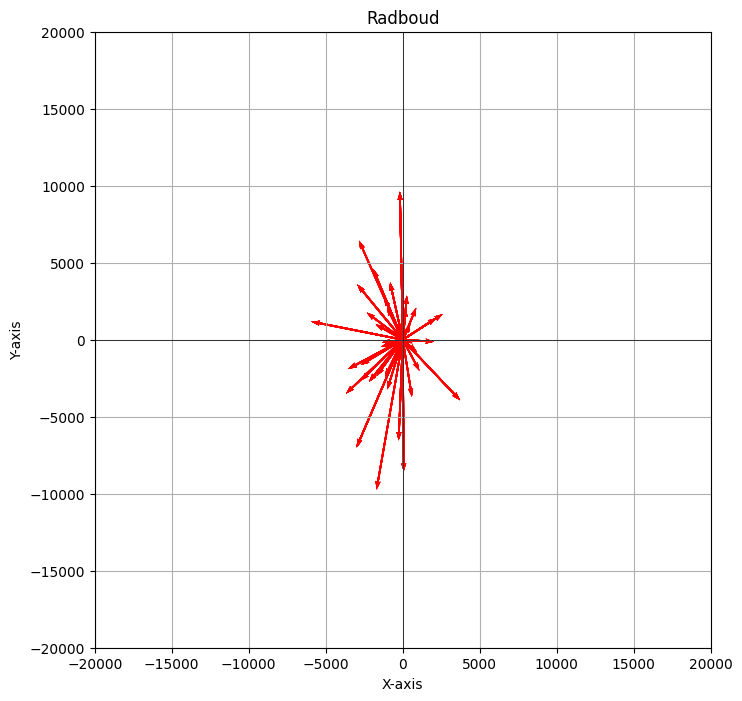

In [57]:
# Processing Jaffe

#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/radboud/HPY.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

jaffe_vectors,jaffe_magnitude =get_resultant_vector(df)

jaffe_angles = get_angles(jaffe_vectors)

plot_vectors(jaffe_vectors,'Radboud')

Skewness of IIM(ANG): 0.358
Skewness of RADBOUD(ANG): 0.965


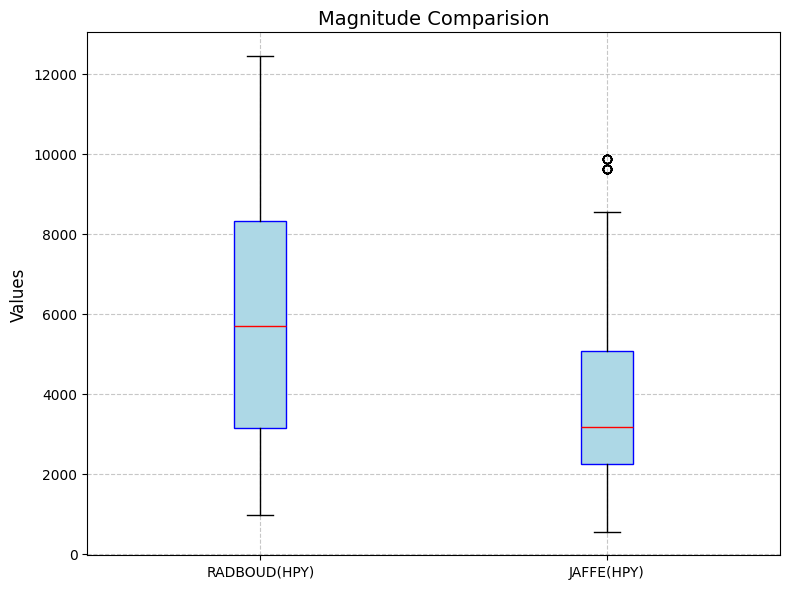

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew


# Calculate skewness
radboud_skewness = skew(radboud_magnitude)
jaffe_skewness = skew(jaffe_magnitude)

# Print skewness
print(f"Skewness of IIM(ANG): {radboud_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")


# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [np.array(radboud_magnitude), np.array(jaffe_magnitude)]
ax.boxplot(boxplot_data, labels=['RADBOUD(HPY)', 'JAFFE(HPY)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Magnitude Comparision', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


Skewness of IIM(ANG): -2.048
Skewness of RADBOUD(ANG): 0.063


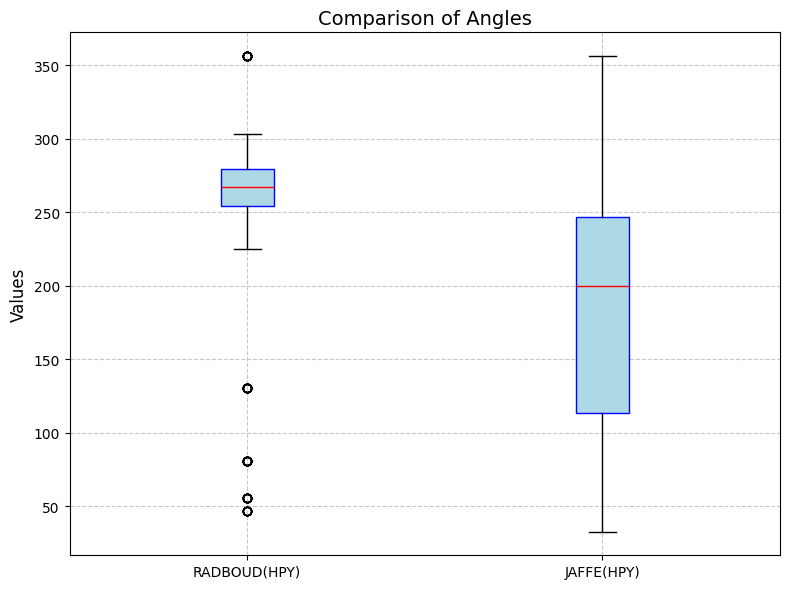

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")


# Calculate skewness
radboud_skewness = skew(radboud_angles)
jaffe_skewness = skew(jaffe_angles)

# Print skewness
print(f"Skewness of IIM(ANG): {radboud_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [radboud_angles, jaffe_angles]
ax.boxplot(boxplot_data, labels=['RADBOUD(HPY)', 'JAFFE(HPY)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Comparison of Angles', fontsize=14)
ax.set_ylabel('Values', fontsize=12)


# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [26]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(radboud_angles, jaffe_angles, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the angles.")
else:
    print("There is no significant difference between the angles.")


Mann-Whitney U Test Statistic: 187343.0, p-value: 1.9356679712170035e-42
There is a significant difference between the angles.


In [27]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(radboud_magnitude, jaffe_magnitude, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 177459.0, p-value: 1.5077815809771048e-30
There is a significant difference between the magnitudes.


In [28]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = radboud_vectors # 10 vectors in group 1
array2 = jaffe_vectors  # 10 vectors in group 2

# Combine arrays and create unique labels
data = np.vstack([array1, array2])
labels = [f'Group1_{i}' for i in range(len(array1))] + [f'Group2_{i}' for i in range(len(array2))]

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=['Group1'] * len(array1) + ['Group2'] * len(array2))
print(result)


method name                PERMANOVA
test statistic name         pseudo-F
sample size                     1000
number of groups                   2
test statistic            291.183142
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object


# SAD

In [30]:
# #SAD
iim_ang = np.array([21, 37, 65, 87, 117, 167, 213, 219, 265, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 365, 385, 389, 399, 401, 403, 405, 409, 417, 421, 423, 429, 431, 525, 547, 577, 627, 671, 677, 723, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 813, 833, 837, 843, 845, 849, 857, 861, 863, 869, 871])
radboud_ang = np.array([37, 65, 87, 117, 167, 213, 271, 273, 277, 281, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 429, 431, 525, 577, 627, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 813, 837, 843, 845, 849, 857, 861, 863, 871])
jaffe_sad = np.array([31, 33, 35, 37, 65, 87, 167, 169, 171, 181, 183, 213, 271, 273, 277, 281, 293, 297, 299, 301, 305, 339, 341, 343, 345, 351, 353, 361, 363, 365, 389, 399, 401, 403, 405, 409, 417, 421, 423, 525, 547, 627, 629, 631, 643, 671, 729, 731, 735, 739, 755, 757, 759, 789, 791, 793, 795, 801, 809, 811, 813, 837, 843, 845, 849, 857, 861, 863])

intersection = np.intersect1d(jaffe_sad, radboud_ang)

In [31]:
intersection = get_both_components(intersection)

(500, 104)


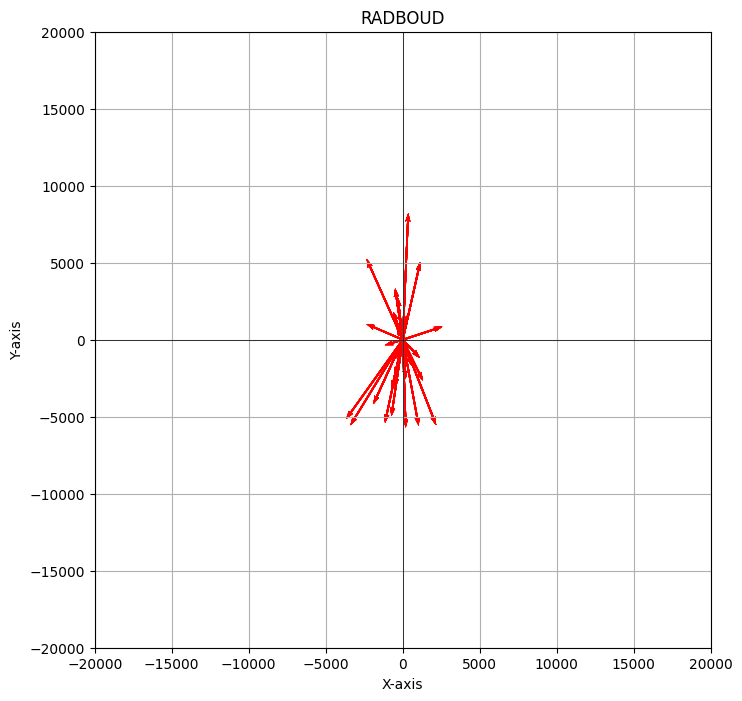

In [34]:
#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/jaffe/SAD.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

jaffe_vectors,jaffe_magnitude =get_resultant_vector(df)

jaffe_angles = get_angles(iim_vectors)

plot_vectors(iim_vectors,'RADBOUD')

(500, 104)


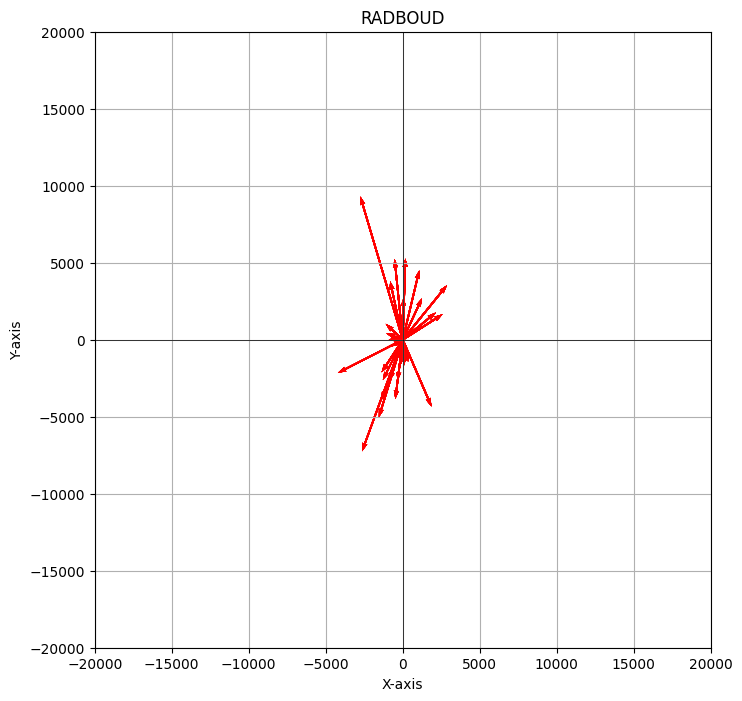

In [35]:
# Processing Jaffe

#  Processing IIM
df = pd.read_csv('landmark_differences_csvs/radboud/SAD.csv')
df = df[[str(x) for x in intersection]]
df = df.sample(500,replace=True,random_state=RANDOM_SEED)
print(df.shape)

radboud_vectors,radboud_magnitude =get_resultant_vector(df)

radboud_angles = get_angles(radboud_vectors)

plot_vectors(jaffe_vectors,'RADBOUD')

Skewness of IIM(ANG): 1.062
Skewness of RADBOUD(ANG): 1.021


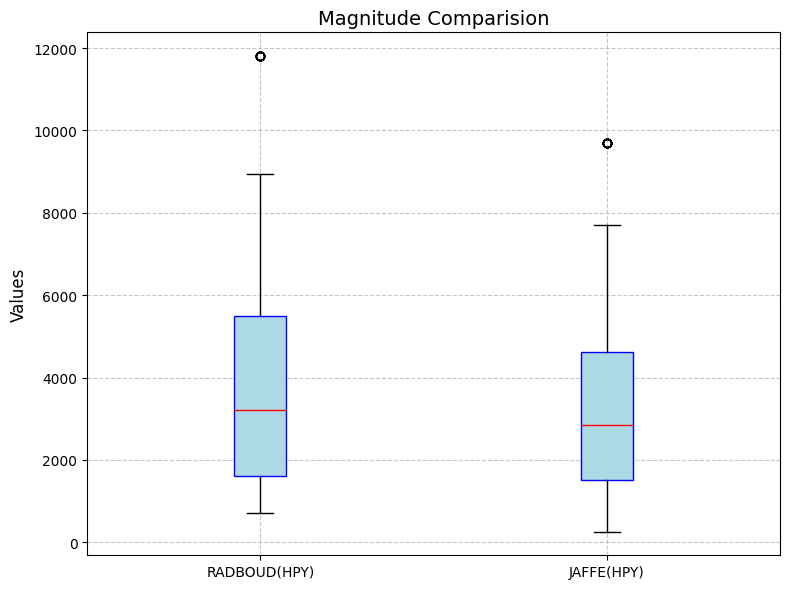

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew


# Calculate skewness
radboud_skewness = skew(radboud_magnitude)
jaffe_skewness = skew(jaffe_magnitude)

# Print skewness
print(f"Skewness of IIM(ANG): {radboud_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")


# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [np.array(radboud_magnitude), np.array(jaffe_magnitude)]
ax.boxplot(boxplot_data, labels=['RADBOUD(HPY)', 'JAFFE(HPY)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Magnitude Comparision', fontsize=14)
ax.set_ylabel('Values', fontsize=12)

# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


Skewness of IIM(ANG): -0.181
Skewness of RADBOUD(ANG): -0.634


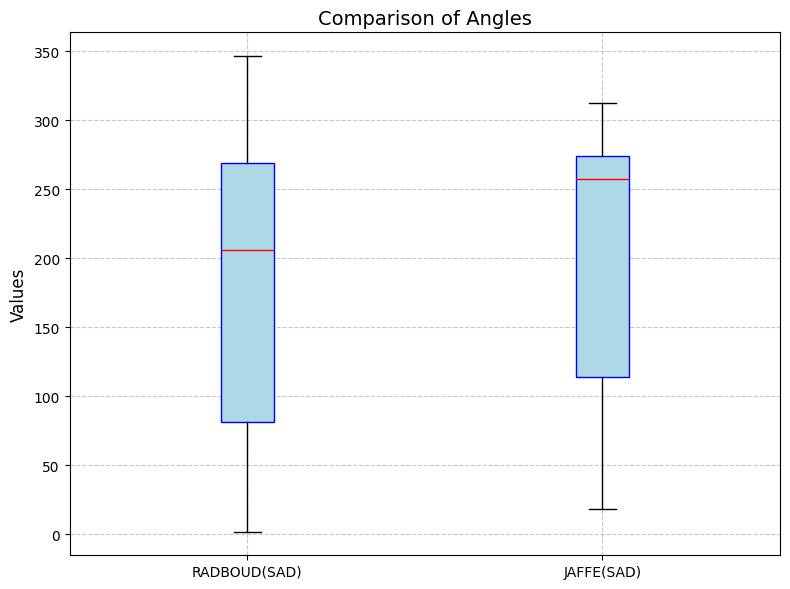

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import warnings

warnings.filterwarnings("ignore")


# Calculate skewness
radboud_skewness = skew(radboud_angles)
jaffe_skewness = skew(jaffe_angles)

# Print skewness
print(f"Skewness of IIM(ANG): {radboud_skewness:.3f}")
print(f"Skewness of RADBOUD(ANG): {jaffe_skewness:.3f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the box plots
boxplot_data = [radboud_angles, jaffe_angles]
ax.boxplot(boxplot_data, labels=['RADBOUD(SAD)', 'JAFFE(SAD)'], patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red'))

# Add title and labels
ax.set_title('Comparison of Angles', fontsize=14)
ax.set_ylabel('Values', fontsize=12)


# Customize grid
ax.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [38]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(radboud_angles, jaffe_angles, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the angles.")
else:
    print("There is no significant difference between the angles.")


Mann-Whitney U Test Statistic: 108104.0, p-value: 0.00021538459849835444
There is a significant difference between the angles.


In [39]:
from scipy.stats import mannwhitneyu

# Perform the test
stat, p = mannwhitneyu(radboud_magnitude, jaffe_magnitude, alternative='two-sided')
print(f"Mann-Whitney U Test Statistic: {stat}, p-value: {p}")

if p < 0.05:
    print("There is a significant difference between the magnitudes.")
else:
    print("There is no significant difference between the magnitudes")


Mann-Whitney U Test Statistic: 142726.0, p-value: 0.0001035881617539783
There is a significant difference between the magnitudes.


In [40]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, DistanceMatrix

# Example data: Two 2D arrays
array1 = radboud_vectors # 10 vectors in group 1
array2 = jaffe_vectors  # 10 vectors in group 2

# Combine arrays and create unique labels
data = np.vstack([array1, array2])
labels = [f'Group1_{i}' for i in range(len(array1))] + [f'Group2_{i}' for i in range(len(array2))]

# Compute pairwise distances (Euclidean distance)
distance_matrix = squareform(pdist(data, metric='euclidean'))

# Create DistanceMatrix object
dist_matrix = DistanceMatrix(distance_matrix, ids=labels)

# Run PERMANOVA
result = permanova(dist_matrix, grouping=['Group1'] * len(array1) + ['Group2'] * len(array2))
print(result)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1000
number of groups                  2
test statistic             2.301392
p-value                       0.117
number of permutations          999
Name: PERMANOVA results, dtype: object
